Ejemplo 1: Dataset mtcars (Consumo de combustible de autos)

Este dataset viene integrado en R y contiene información sobre el diseño y rendimiento de 32 automóviles de 1973-1974.

'data.frame':	32 obs. of  11 variables:
 $ mpg : num  21 21 22.8 21.4 18.7 18.1 14.3 24.4 22.8 19.2 ...
 $ cyl : num  6 6 4 6 8 6 8 4 4 6 ...
 $ disp: num  160 160 108 258 360 ...
 $ hp  : num  110 110 93 110 175 105 245 62 95 123 ...
 $ drat: num  3.9 3.9 3.85 3.08 3.15 2.76 3.21 3.69 3.92 3.92 ...
 $ wt  : num  2.62 2.88 2.32 3.21 3.44 ...
 $ qsec: num  16.5 17 18.6 19.4 17 ...
 $ vs  : num  0 0 1 1 0 1 0 1 1 1 ...
 $ am  : num  1 1 1 0 0 0 0 0 0 0 ...
 $ gear: num  4 4 4 3 3 3 3 4 4 4 ...
 $ carb: num  4 4 1 1 2 1 4 2 2 4 ...


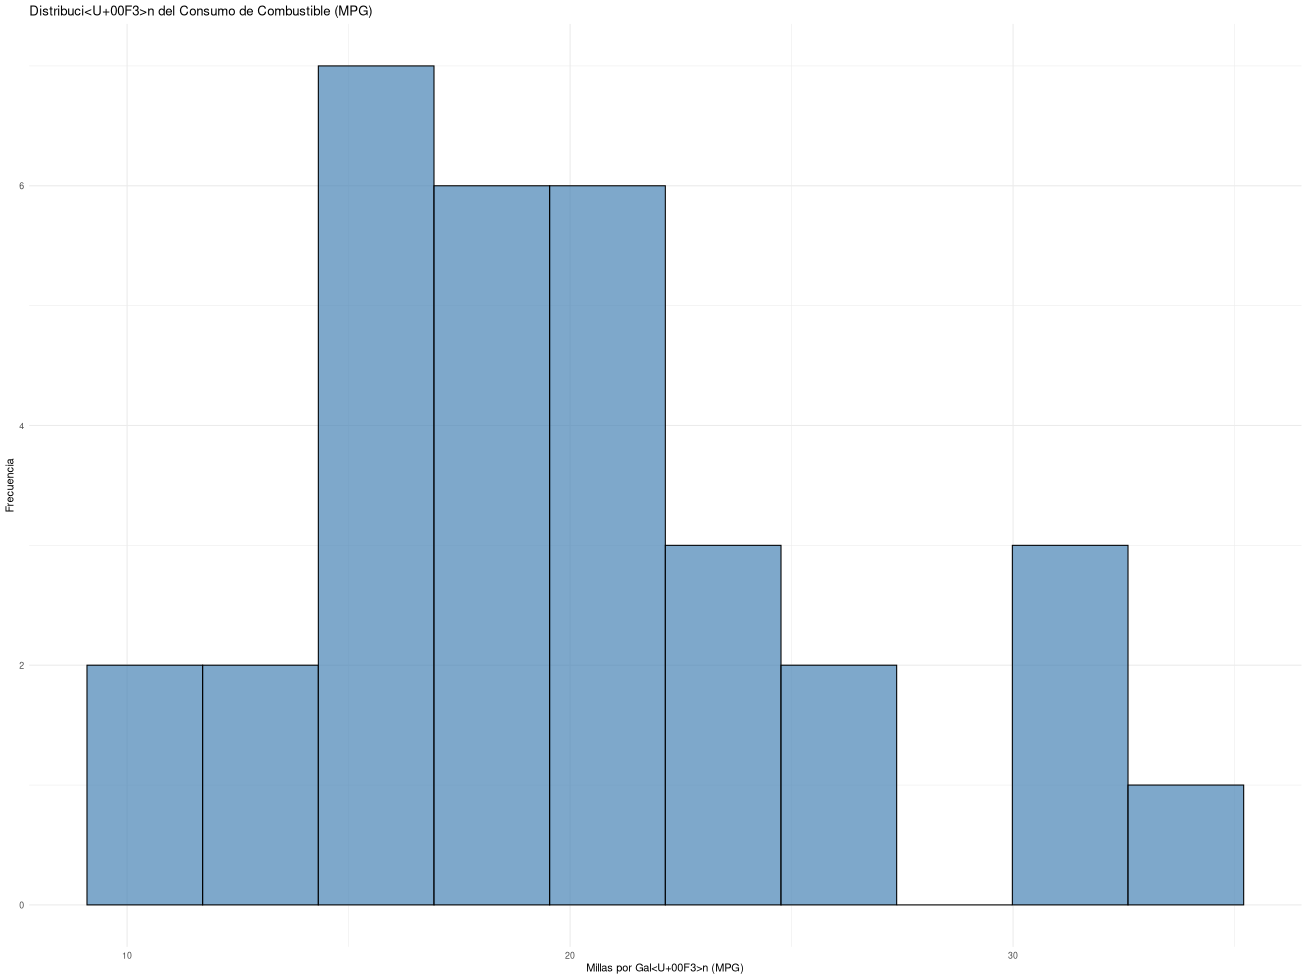

Warning message:
`aes_string()` was deprecated in ggplot2 3.0.0.
i Please use tidy evaluation idioms with `aes()`.
i See also `vignette("ggplot2-in-packages")` for more information.
i The deprecated feature was likely used in the ggcorrplot package.
  Please report the issue at <]8;;https://github.com/kassambara/ggcorrplot/issueshttps://github.com/kassambara/ggcorrplot/issues]8;;>.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was
generated. 


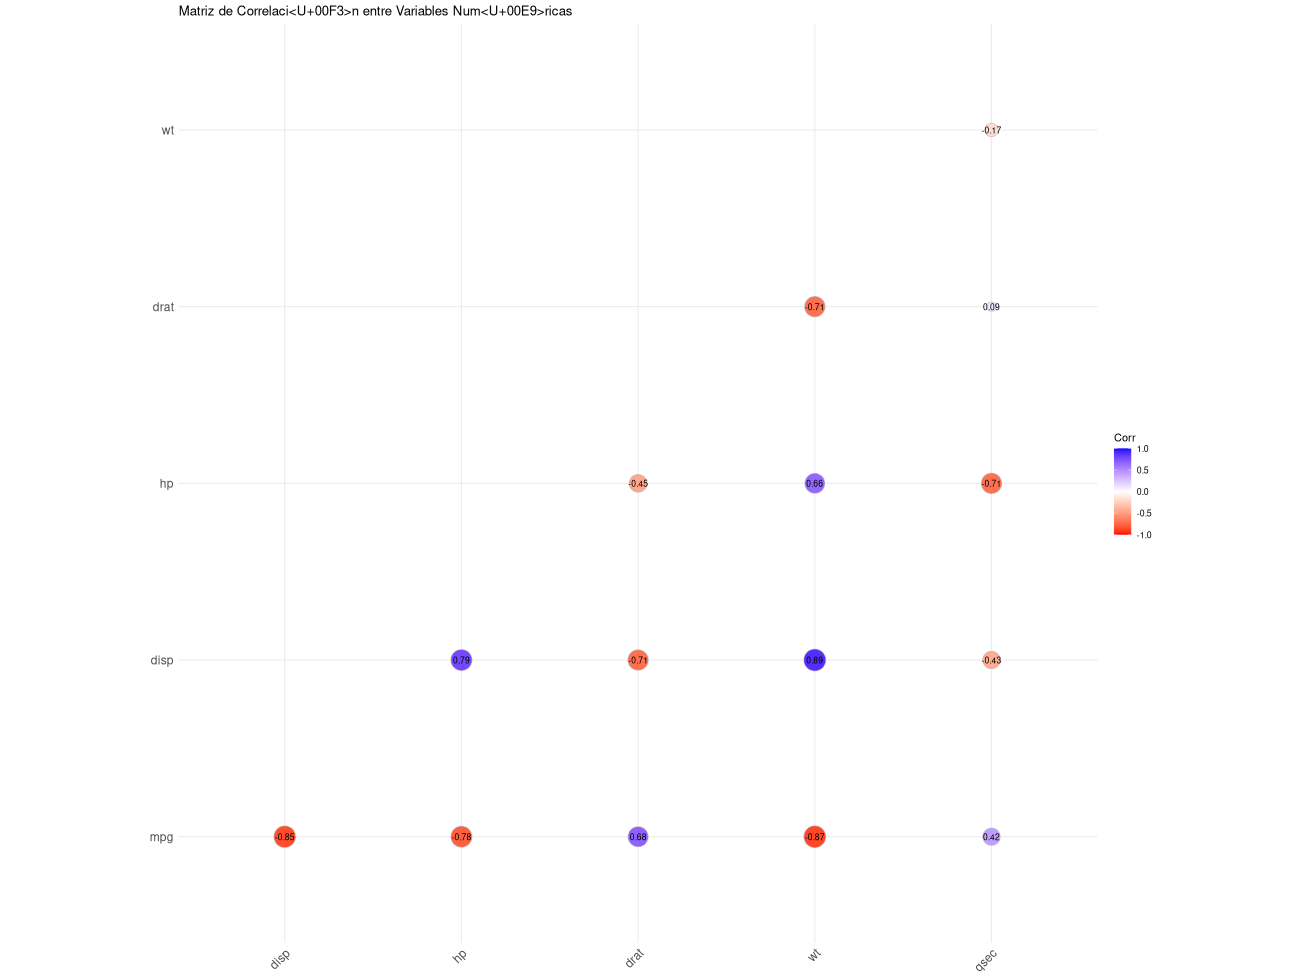

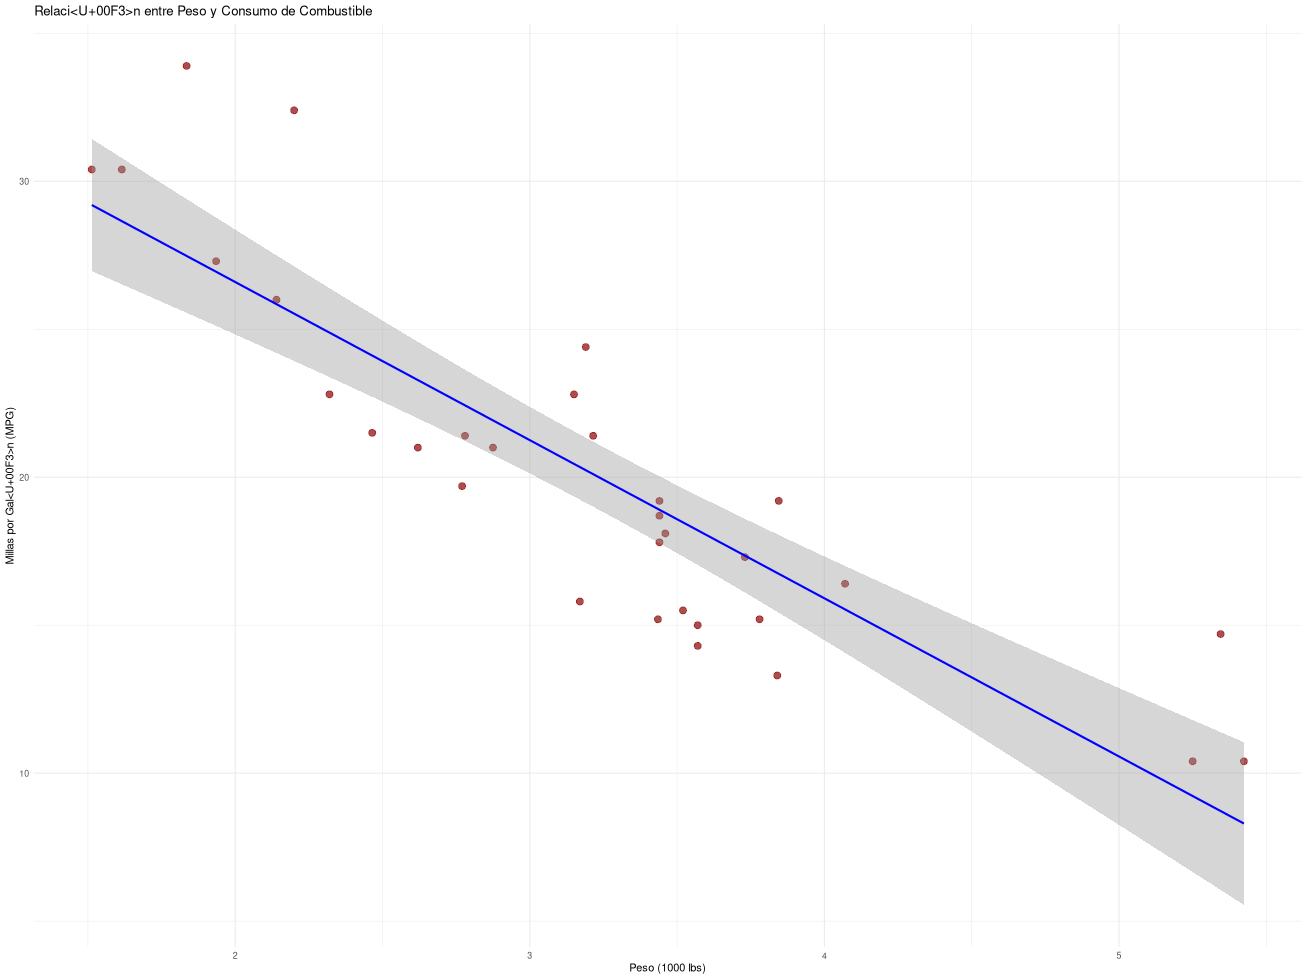

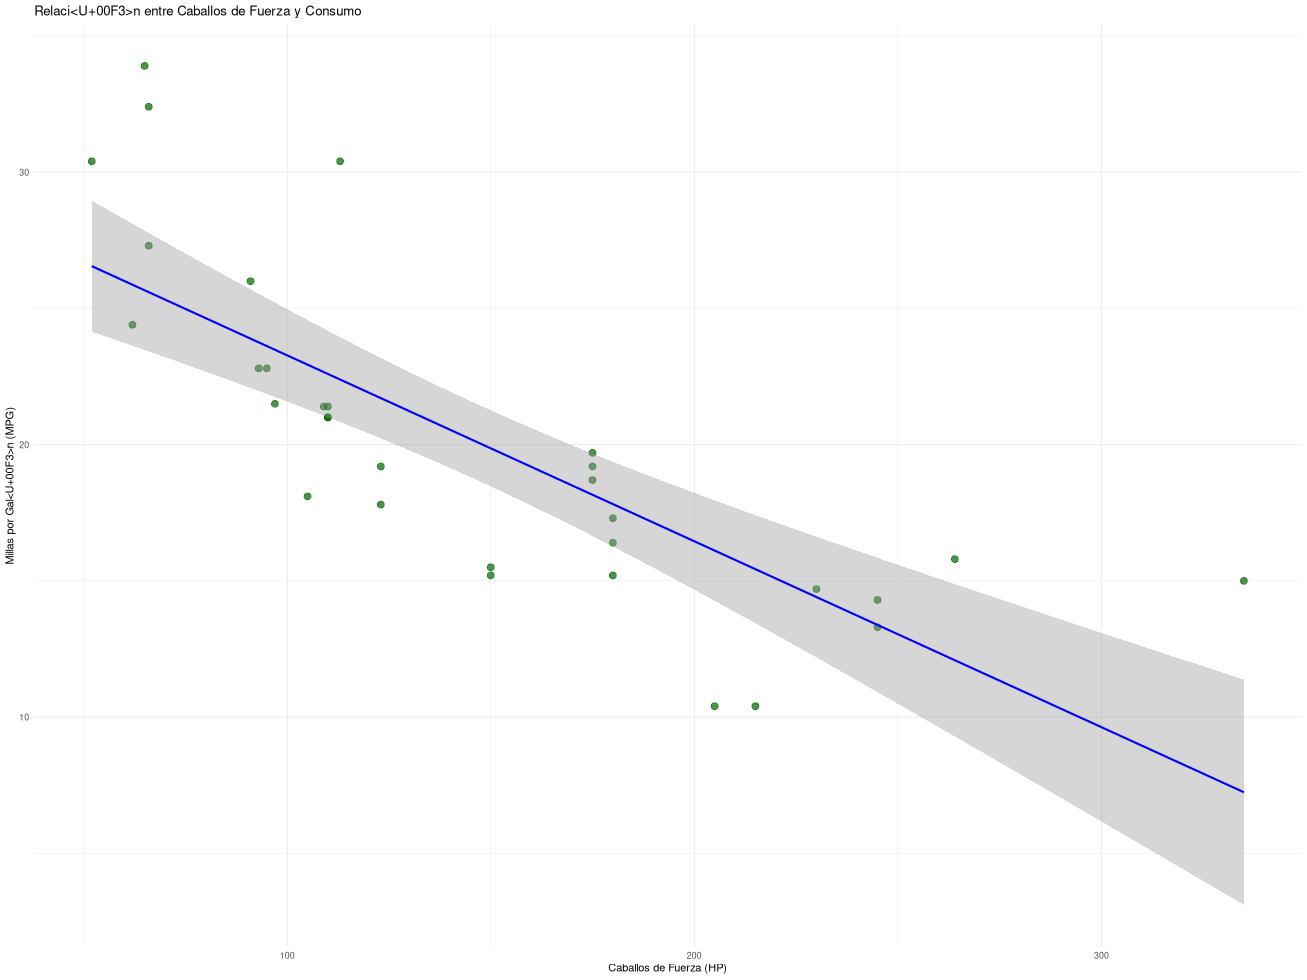

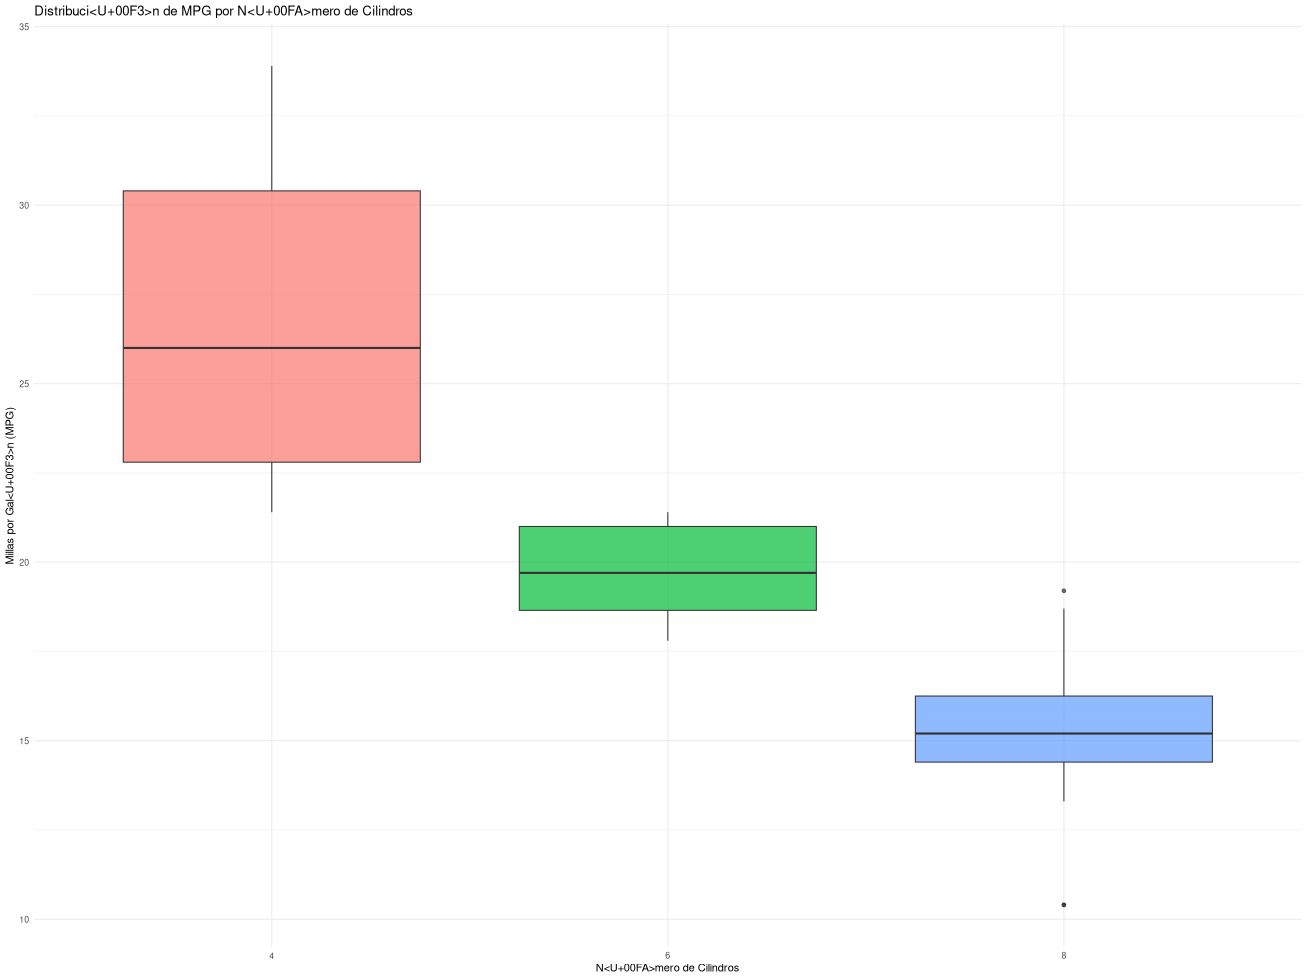

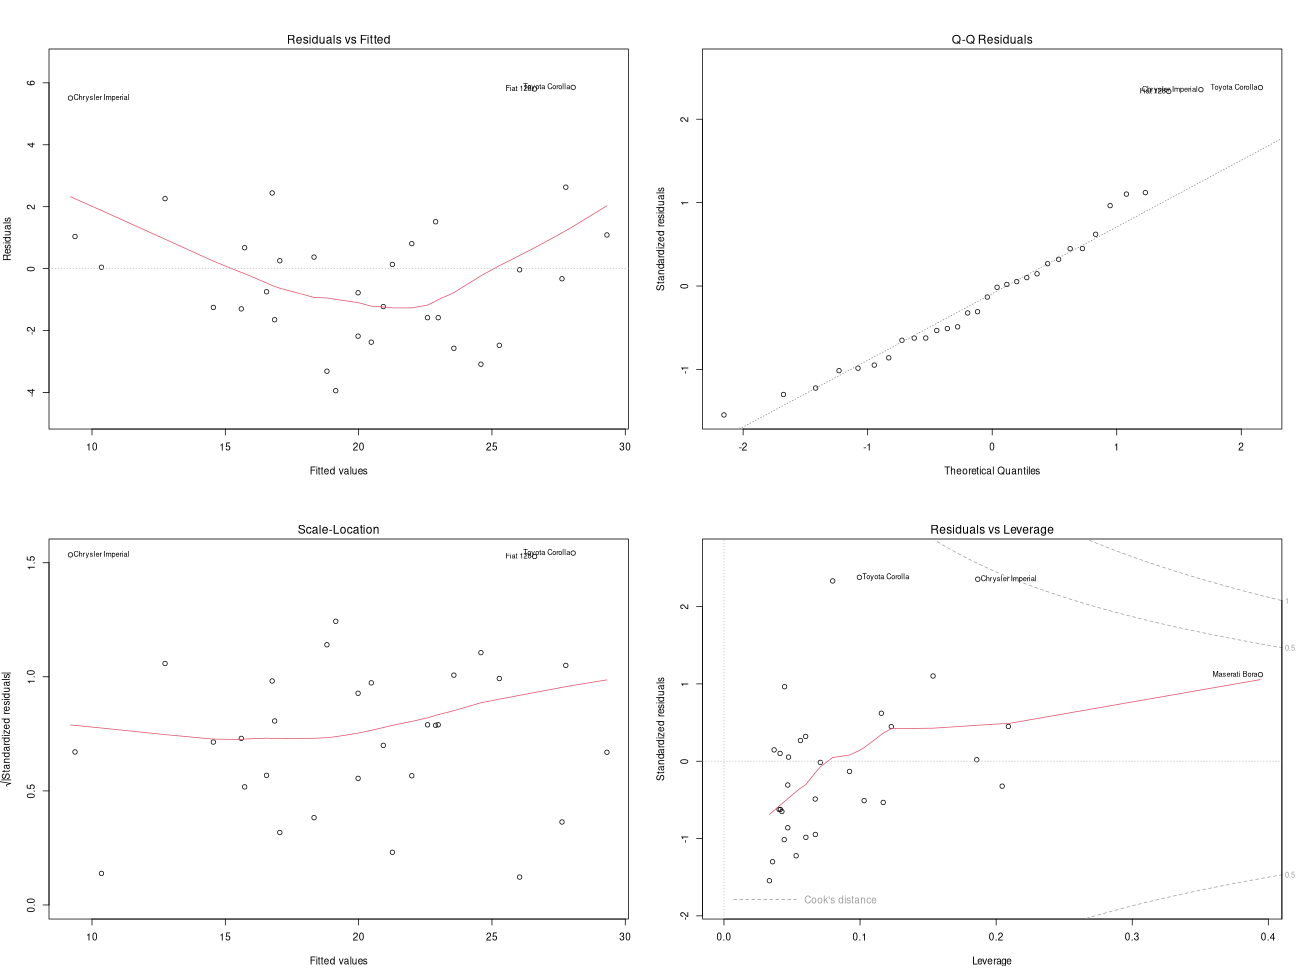

Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was
generated. 



=== INTERPRETACI<U+00D3>N DEL MODELO ===
Coeficientes:
(Intercept)          wt          hp 
37.22727012 -3.87783074 -0.03177295 

R-cuadrado ajustado: 0.8148396 
Esto significa que el modelo explica aproximadamente 81.48 % de la variabilidad en MPG


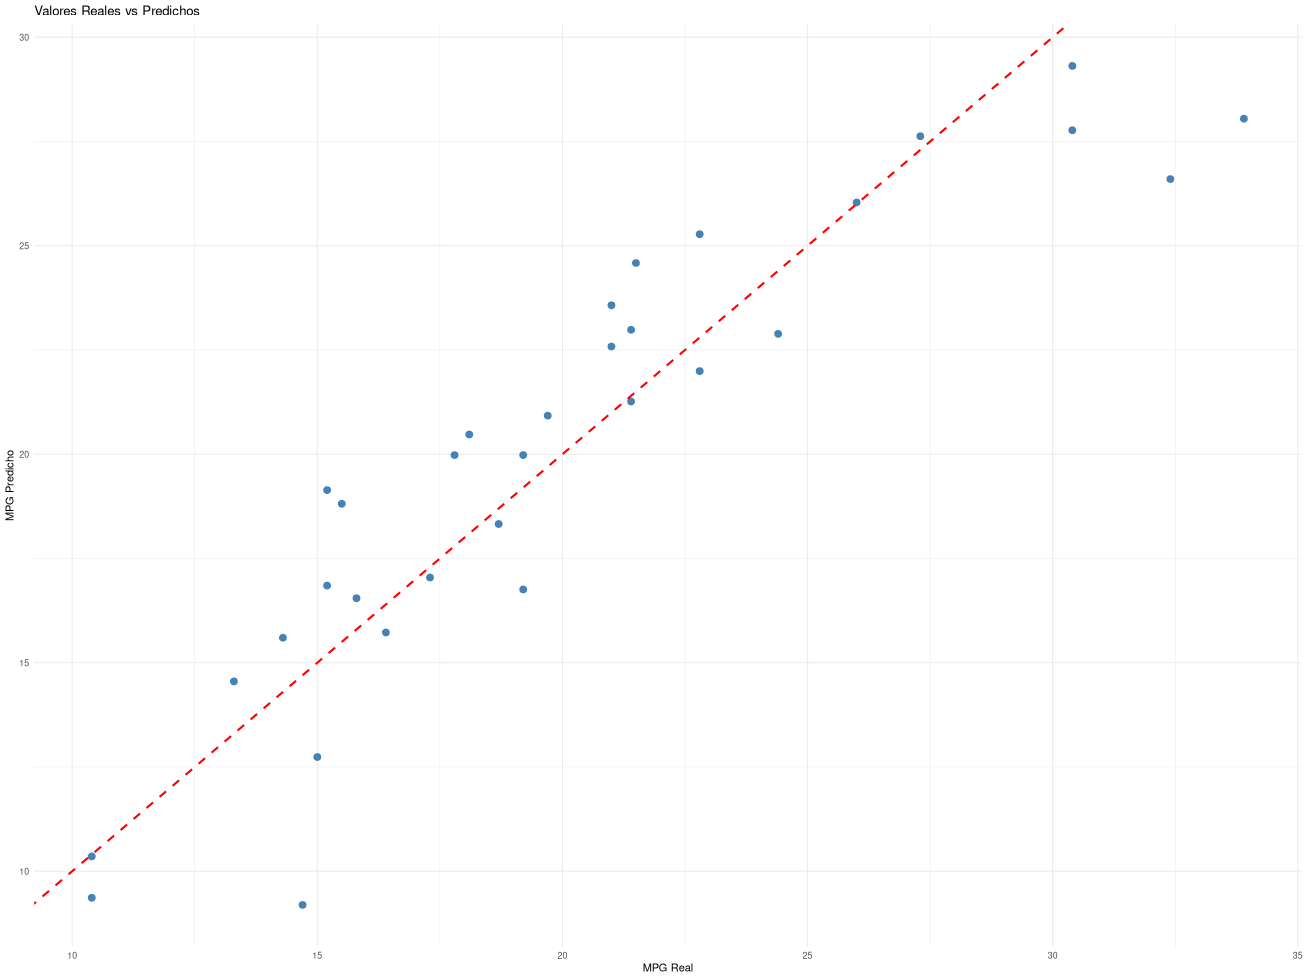

In [4]:
# ============================================
# EJEMPLO 1: mtcars - Predicción de MPG
# ============================================

# Cargar librerías necesarias
library(ggplot2)
library(dplyr)
library(ggcorrplot)

# 1. Cargar los datos (viene en R base)
data(mtcars)
df_mtcars <- mtcars

# ============================================
# ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ============================================

# Ver estructura de los datos
str(df_mtcars)
head(df_mtcars)

# Resumen estadístico
summary(df_mtcars)

# Convertir variables categóricas
df_mtcars$cyl <- as.factor(df_mtcars$cyl)
df_mtcars$gear <- as.factor(df_mtcars$gear)

# Histograma de la variable objetivo (MPG)
ggplot(df_mtcars, aes(x = mpg)) +
  geom_histogram(bins = 10, fill = "steelblue", color = "black", alpha = 0.7) +
  labs(title = "Distribución del Consumo de Combustible (MPG)",
       x = "Millas por Galón (MPG)",
       y = "Frecuencia") +
  theme_minimal()

# Matriz de correlación para variables numéricas
numeric_vars <- df_mtcars %>% select(mpg, disp, hp, drat, wt, qsec)
cor_matrix <- cor(numeric_vars)

# Gráfico de correlación
ggcorrplot(cor_matrix, method = "circle", type = "lower", 
           lab = TRUE, lab_size = 3, colors = c("red", "white", "blue"),
           title = "Matriz de Correlación entre Variables Numéricas",
           ggtheme = theme_minimal())

# Scatter plots: MPG vs Peso (wt) y MPG vs Caballos de fuerza (hp)
ggplot(df_mtcars, aes(x = wt, y = mpg)) +
  geom_point(size = 3, color = "darkred", alpha = 0.7) +
  geom_smooth(method = "lm", se = TRUE, color = "blue") +
  labs(title = "Relación entre Peso y Consumo de Combustible",
       x = "Peso (1000 lbs)",
       y = "Millas por Galón (MPG)") +
  theme_minimal()

ggplot(df_mtcars, aes(x = hp, y = mpg)) +
  geom_point(size = 3, color = "darkgreen", alpha = 0.7) +
  geom_smooth(method = "lm", se = TRUE, color = "blue") +
  labs(title = "Relación entre Caballos de Fuerza y Consumo",
       x = "Caballos de Fuerza (HP)",
       y = "Millas por Galón (MPG)") +
  theme_minimal()

# Boxplot de MPG por número de cilindros
ggplot(df_mtcars, aes(x = cyl, y = mpg, fill = cyl)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Distribución de MPG por Número de Cilindros",
       x = "Número de Cilindros",
       y = "Millas por Galón (MPG)") +
  theme_minimal() +
  theme(legend.position = "none")

# ============================================
# MODELO DE REGRESIÓN LINEAL
# ============================================

# Modelo simple: predecir MPG usando peso
modelo_simple <- lm(mpg ~ wt, data = df_mtcars)
summary(modelo_simple)

# Modelo múltiple: predecir MPG usando peso y caballos de fuerza
modelo_multiple <- lm(mpg ~ wt + hp, data = df_mtcars)
summary(modelo_multiple)

# ============================================
# DIAGNÓSTICO DEL MODELO
# ============================================

# Gráficos de diagnóstico (4 en 1)
par(mfrow = c(2, 2))
plot(modelo_multiple)
par(mfrow = c(1, 1))

# Gráfico de valores ajustados vs reales
ggplot(data.frame(Real = df_mtcars$mpg, 
                  Predicho = fitted(modelo_multiple)),
       aes(x = Real, y = Predicho)) +
  geom_point(size = 3, color = "steelblue") +
  geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed", size = 1) +
  labs(title = "Valores Reales vs Predichos",
       x = "MPG Real",
       y = "MPG Predicho") +
  theme_minimal()

# Interpretación
cat("\n=== INTERPRETACIÓN DEL MODELO ===\n")
cat("Coeficientes:\n")
print(coef(modelo_multiple))
cat("\nR-cuadrado ajustado:", summary(modelo_multiple)$adj.r.squared, "\n")
cat("Esto significa que el modelo explica aproximadamente", 
    round(summary(modelo_multiple)$adj.r.squared * 100, 2), 
    "% de la variabilidad en MPG\n")

### Ejemplo 2: Dataset iris (Mediciones de flores Iris)

In [7]:
# ============================================
# EJEMPLO 2: iris - Predicción de longitud del pétalo
# ============================================

# Cargar librerías
library(ggplot2)
library(dplyr)
library(GGally)

# 1. Cargar datos
data(iris)
df_iris <- iris

# ============================================
# ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ============================================

# Ver estructura
str(df_iris)
head(df_iris)
summary(df_iris)

# Verificar valores faltantes
cat("Valores faltantes:", sum(is.na(df_iris)), "\n")

# Histogramas de todas las variables numéricas
ggplot(df_iris) +
  geom_histogram(aes(x = Sepal.Length, fill = "Sepal.Length"), alpha = 0.6, bins = 15) +
  geom_histogram(aes(x = Sepal.Width, fill = "Sepal.Width"), alpha = 0.6, bins = 15) +
  geom_histogram(aes(x = Petal.Length, fill = "Petal.Length"), alpha = 0.6, bins = 15) +
  geom_histogram(aes(x = Petal.Width, fill = "Petal.Width"), alpha = 0.6, bins = 15) +
  facet_wrap(~variable, scales = "free_x") +
  labs(title = "Distribución de las Variables del Dataset Iris") +
  theme_minimal()

# Matriz de dispersión (pairs plot)
ggpairs(df_iris, 
        columns = 1:4, 
        aes(color = Species, alpha = 0.7),
        title = "Matriz de Dispersión por Especie") +
  theme_minimal()

# Scatter plot específico: Longitud vs Ancho del pétalo
ggplot(df_iris, aes(x = Petal.Width, y = Petal.Length, color = Species)) +
  geom_point(size = 3, alpha = 0.7) +
  geom_smooth(method = "lm", se = TRUE, size = 1) +
  labs(title = "Longitud vs Ancho del Pétalo por Especie",
       x = "Ancho del Pétalo (cm)",
       y = "Longitud del Pétalo (cm)",
       color = "Especie") +
  theme_minimal()

# Boxplots por especie
ggplot(df_iris, aes(x = Species, y = Petal.Length, fill = Species)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Distribución de Longitud del Pétalo por Especie",
       x = "Especie",
       y = "Longitud del Pétalo (cm)") +
  theme_minimal() +
  theme(legend.position = "none")

# ============================================
# MODELO DE REGRESIÓN LINEAL
# ============================================

# Filtrar solo una especie para regresión simple (setosa)
df_setosa <- df_iris %>% filter(Species == "setosa")

# Modelo: predecir longitud del pétalo usando ancho del pétalo
modelo_iris <- lm(Petal.Length ~ Petal.Width, data = df_setosa)
summary(modelo_iris)

# Modelo usando todo el dataset (con especie como variable categórica)
modelo_iris_completo <- lm(Petal.Length ~ Petal.Width + Species, data = df_iris)
summary(modelo_iris_completo)

# ============================================
# DIAGNÓSTICO DEL MODELO
# ============================================

# Gráficos de diagnóstico
par(mfrow = c(2, 2))
plot(modelo_iris_completo)
par(mfrow = c(1, 1))

# Gráfico de residuos
ggplot(data.frame(Fitted = fitted(modelo_iris_completo),
                  Residuals = resid(modelo_iris_completo)),
       aes(x = Fitted, y = Residuals)) +
  geom_point(size = 3, color = "darkgreen", alpha = 0.7) +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed", size = 1) +
  labs(title = "Residuos vs Valores Ajustados",
       x = "Valores Ajustados",
       y = "Residuos") +
  theme_minimal()

# Interpretación
cat("\n=== INTERPRETACIÓN DEL MODELO ===\n")
cat("Coeficientes:\n")
print(coef(modelo_iris_completo))
cat("\nR-cuadrado ajustado:", summary(modelo_iris_completo)$adj.r.squared, "\n")

'data.frame':	150 obs. of  5 variables:
 $ Sepal.Length: num  5.1 4.9 4.7 4.6 5 5.4 4.6 5 4.4 4.9 ...
 $ Sepal.Width : num  3.5 3 3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 ...
 $ Petal.Length: num  1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 ...
 $ Petal.Width : num  0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 ...
 $ Species     : Factor w/ 3 levels "setosa","versicolor",..: 1 1 1 1 1 1 1 1 1 1 ...
Valores faltantes: 0 


: [1m[33mError[39m in `combine_vars()`:[22m
[1m[22m[33m![39m At least one layer must contain all faceting variables: `variable`
[31mx[39m Plot is missing `variable`
[31mx[39m Layer 1 is missing `variable`
[31mx[39m Layer 2 is missing `variable`
[31mx[39m Layer 3 is missing `variable`
[31mx[39m Layer 4 is missing `variable`

### Ejemplo 3: Dataset Auto MPG (UCI Machine Learning Repository)
Dataset real descargado de internet con información sobre consumo de combustible de automóviles.


-- Column specification --------------------------------------------------------
cols(
  X1 = col_double(),
  X2 = col_double(),
  X3 = col_double(),
  X4 = col_character(),
  X5 = col_double(),
  X6 = col_double(),
  X7 = col_double(),
  X8 = col_double(),
  X9 = col_character(),
  X10 = col_character(),
  X11 = col_character()
)



row col   expected     actual                                                                               file
  3  -- 11 columns 10 columns 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
  5  -- 11 columns 10 columns 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
  7  -- 11 columns 10 columns 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
  9  -- 11 columns 10 columns 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
 14  -- 11 columns 12 columns 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
... ... .......... .......... ..................................................................................
See problems(...) for more details.



spc_tbl_ [398 x 11] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ mpg         : num [1:398] 18 15 18 16 17 15 14 14 14 15 ...
 $ cylinders   : num [1:398] 8 8 8 8 8 8 8 8 8 8 ...
 $ displacement: num [1:398] 307 350 318 304 302 429 454 440 455 390 ...
 $ horsepower  : chr [1:398] "130.0" "165.0" "150.0" "150.0" ...
 $ weight      : num [1:398] 3504 3693 3436 3433 3449 ...
 $ acceleration: num [1:398] 12 11.5 11 12 10.5 10 9 8.5 10 8.5 ...
 $ year        : num [1:398] 70 70 70 70 70 70 70 70 70 70 ...
 $ origin      : num [1:398] 1 1 1 1 1 1 1 1 1 1 ...
 $ name        : chr [1:398] "\"chevrolet" "\"buick" "\"plymouth" "\"amc" ...
 $ NA          : chr [1:398] "chevelle" "skylark" "satellite\"" "rebel" ...
 $ NA          : chr [1:398] "malibu\"" "320\"" NA "sst\"" ...
 - attr(*, "problems")= tibble [246 x 5] (S3: tbl_df/tbl/data.frame)
  ..$ row     : int [1:246] 3 5 7 9 14 15 16 17 18 19 ...
  ..$ col     : chr [1:246] NA NA NA NA ...
  ..$ expected: chr [1:246] "11 columns" "11 columns" "1

Warning message:
NAs introduced by coercion 


Filas originales: 398 
Filas despu<U+00E9>s de limpieza: 194 


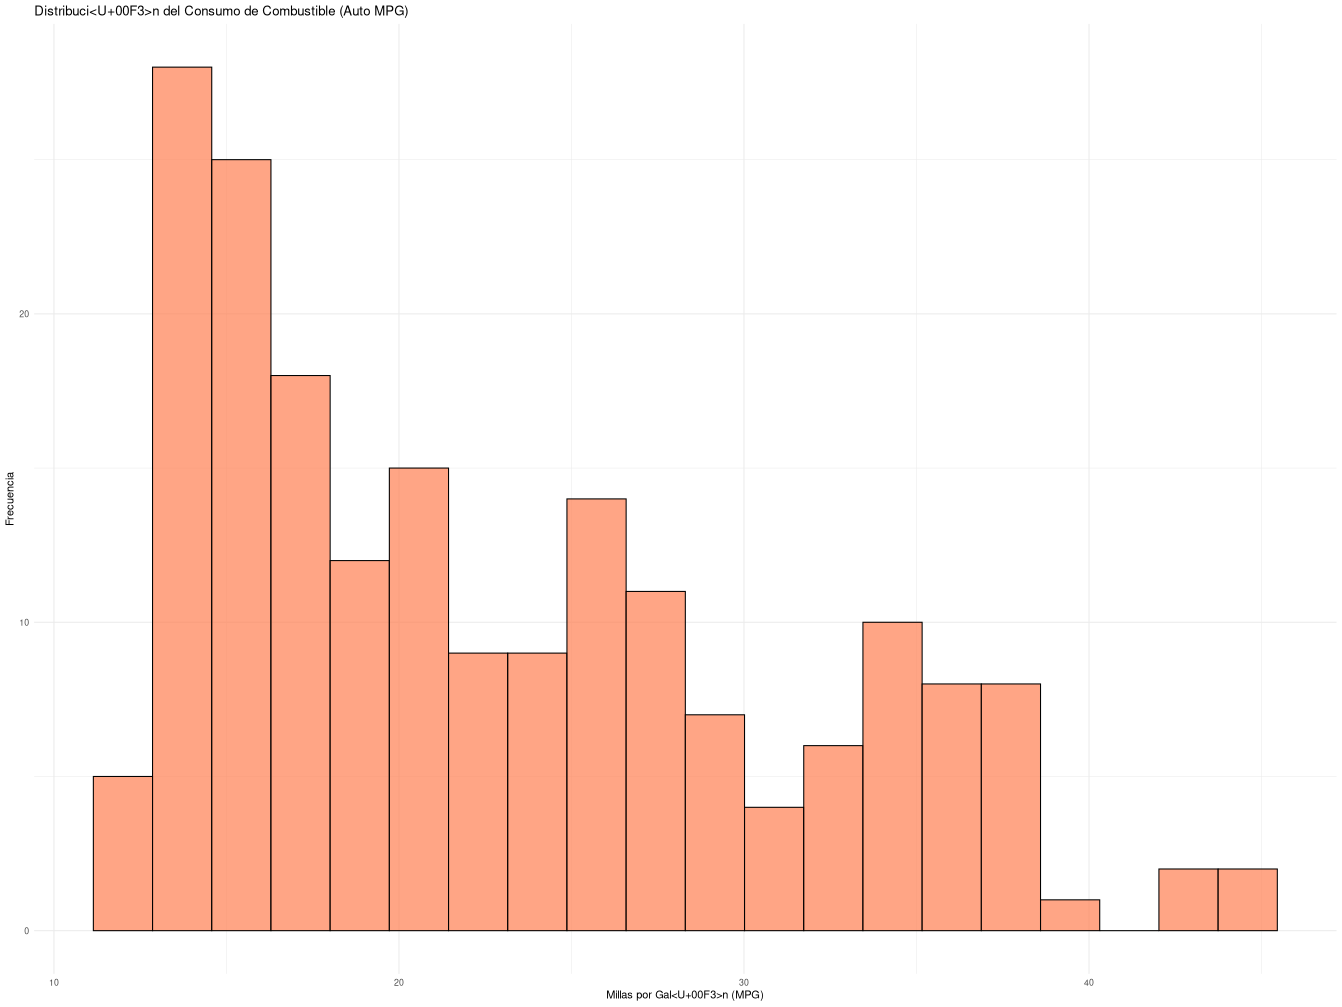

Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was
generated. 


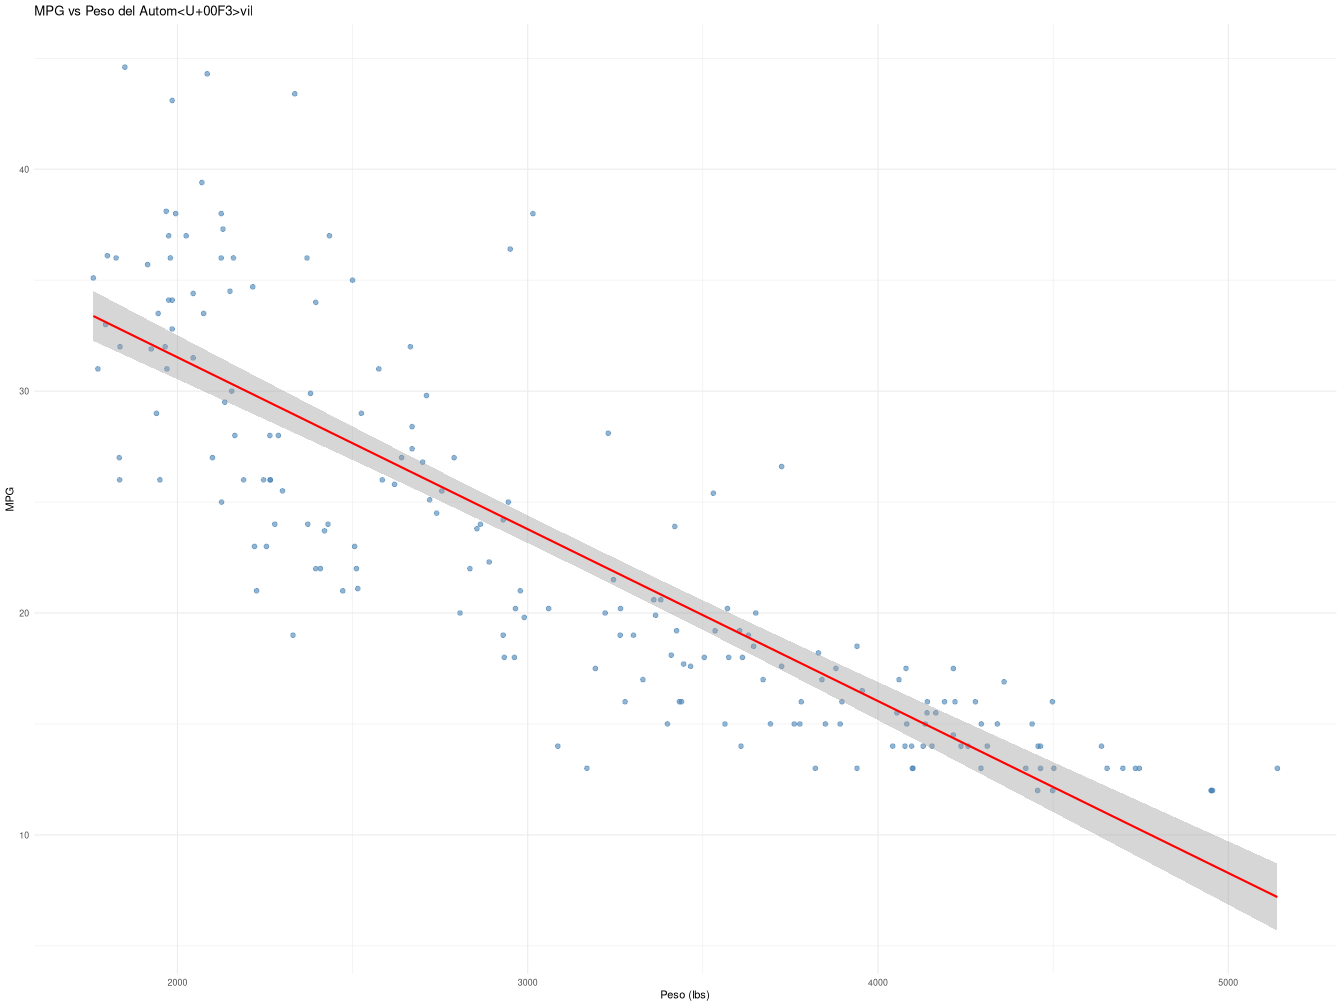

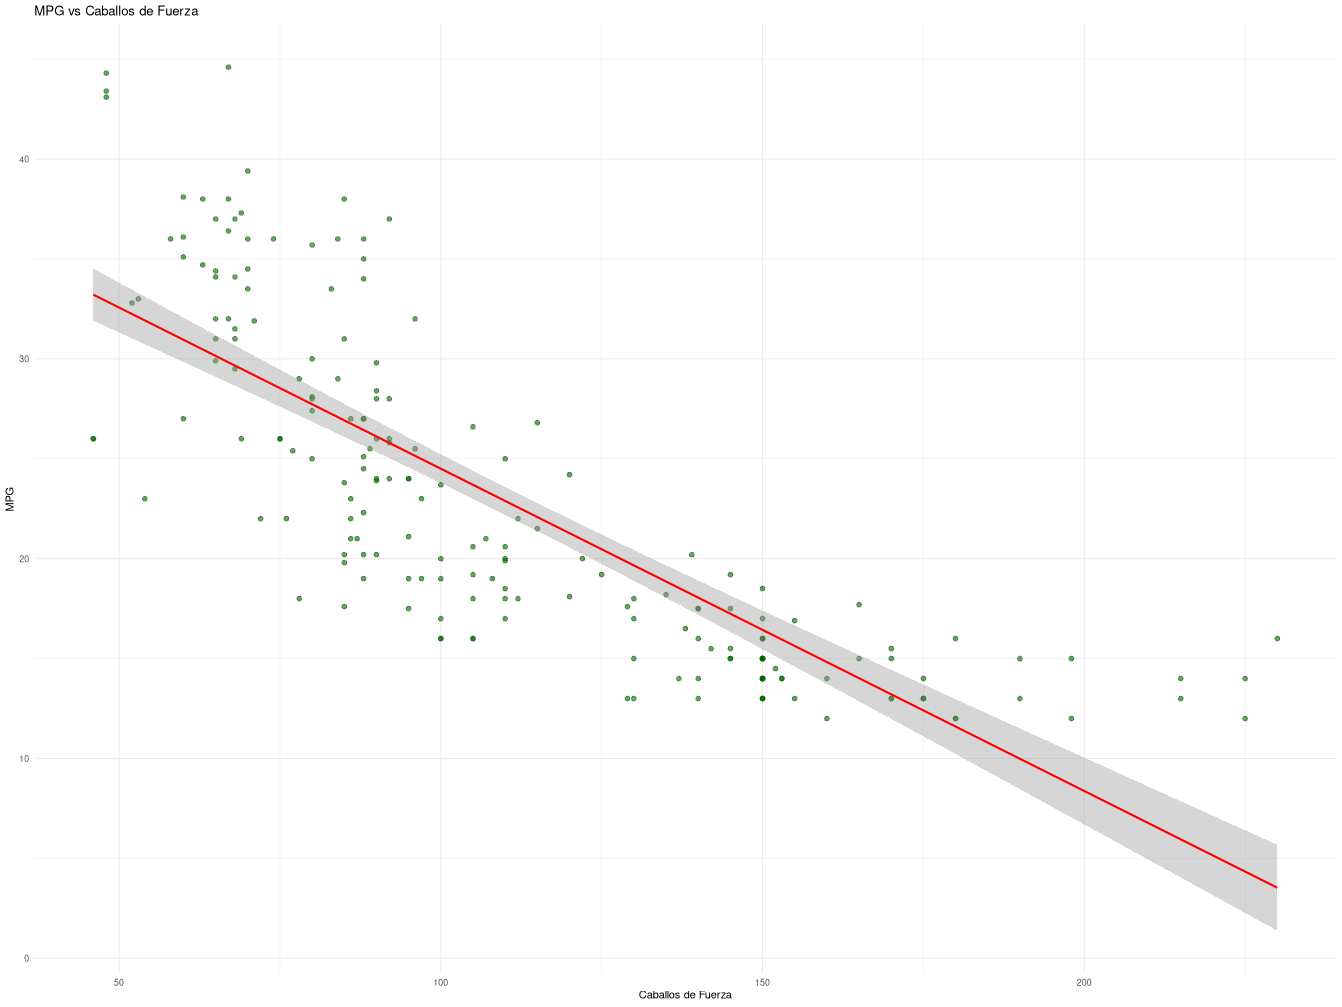

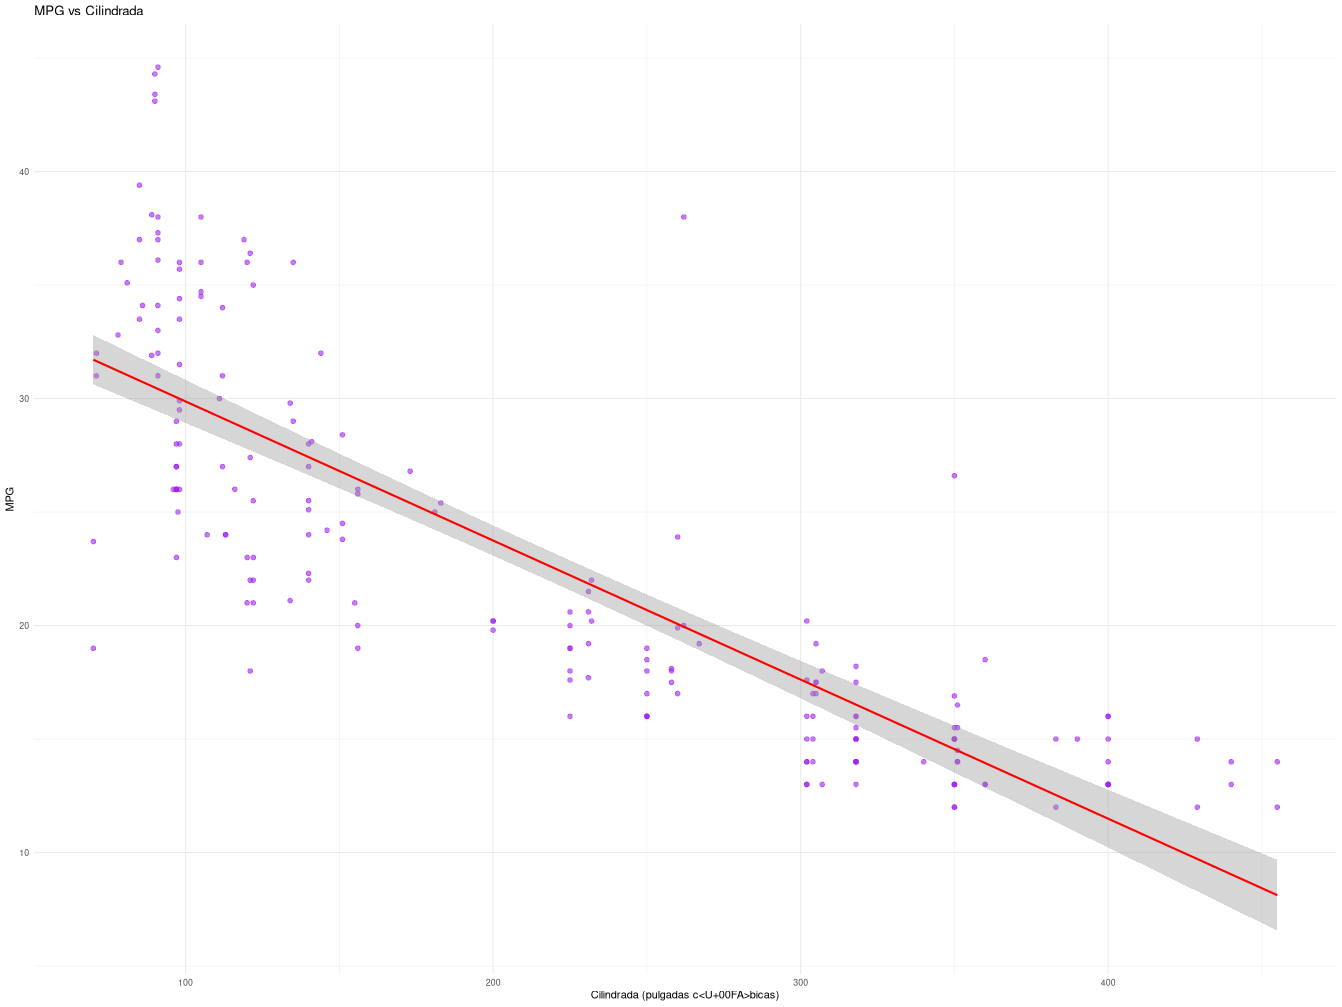

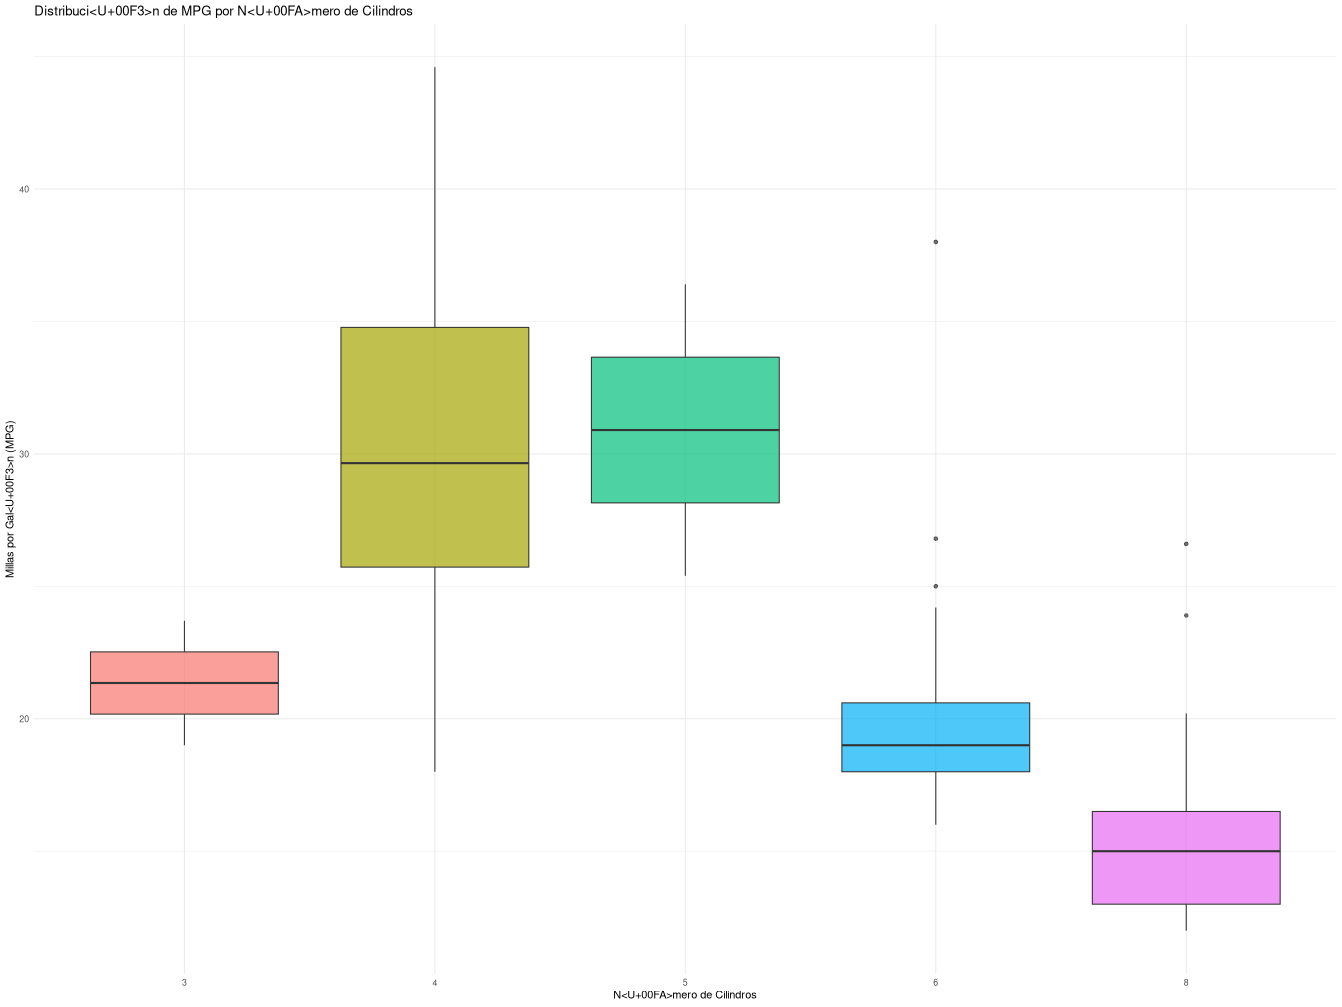

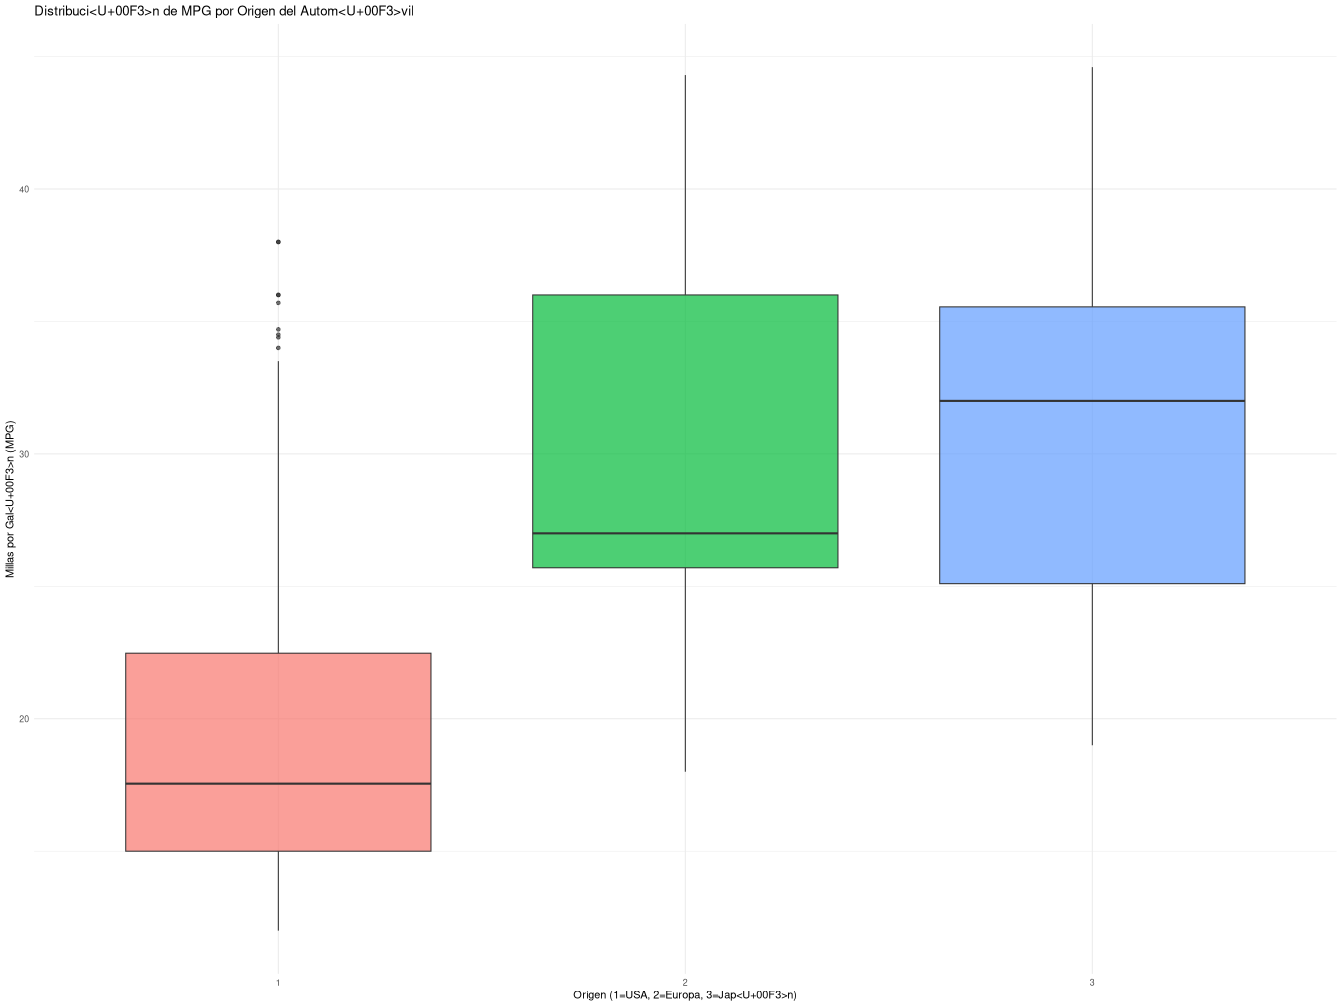

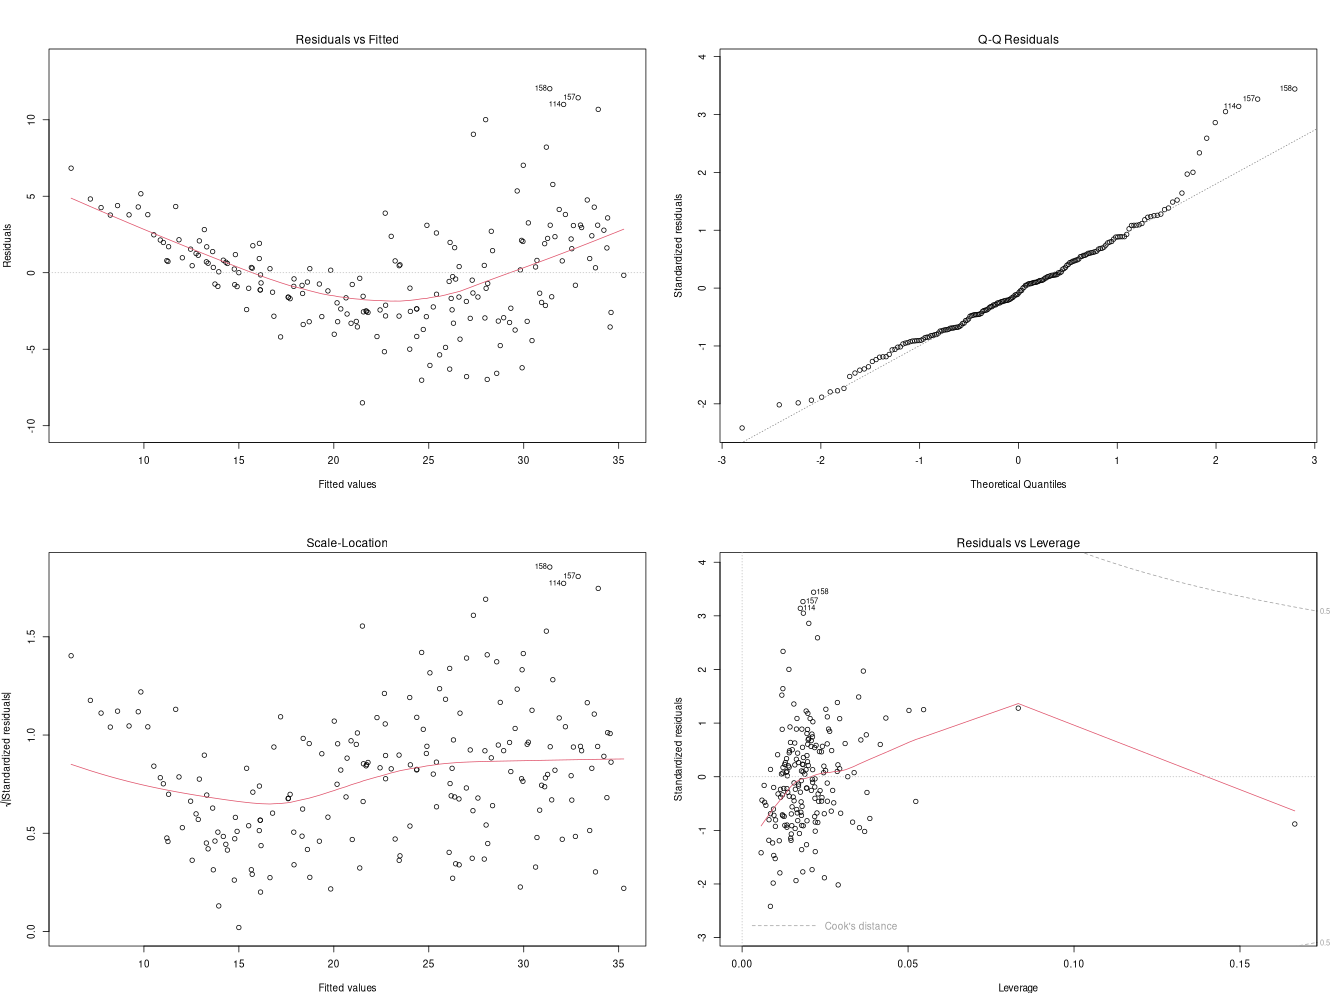

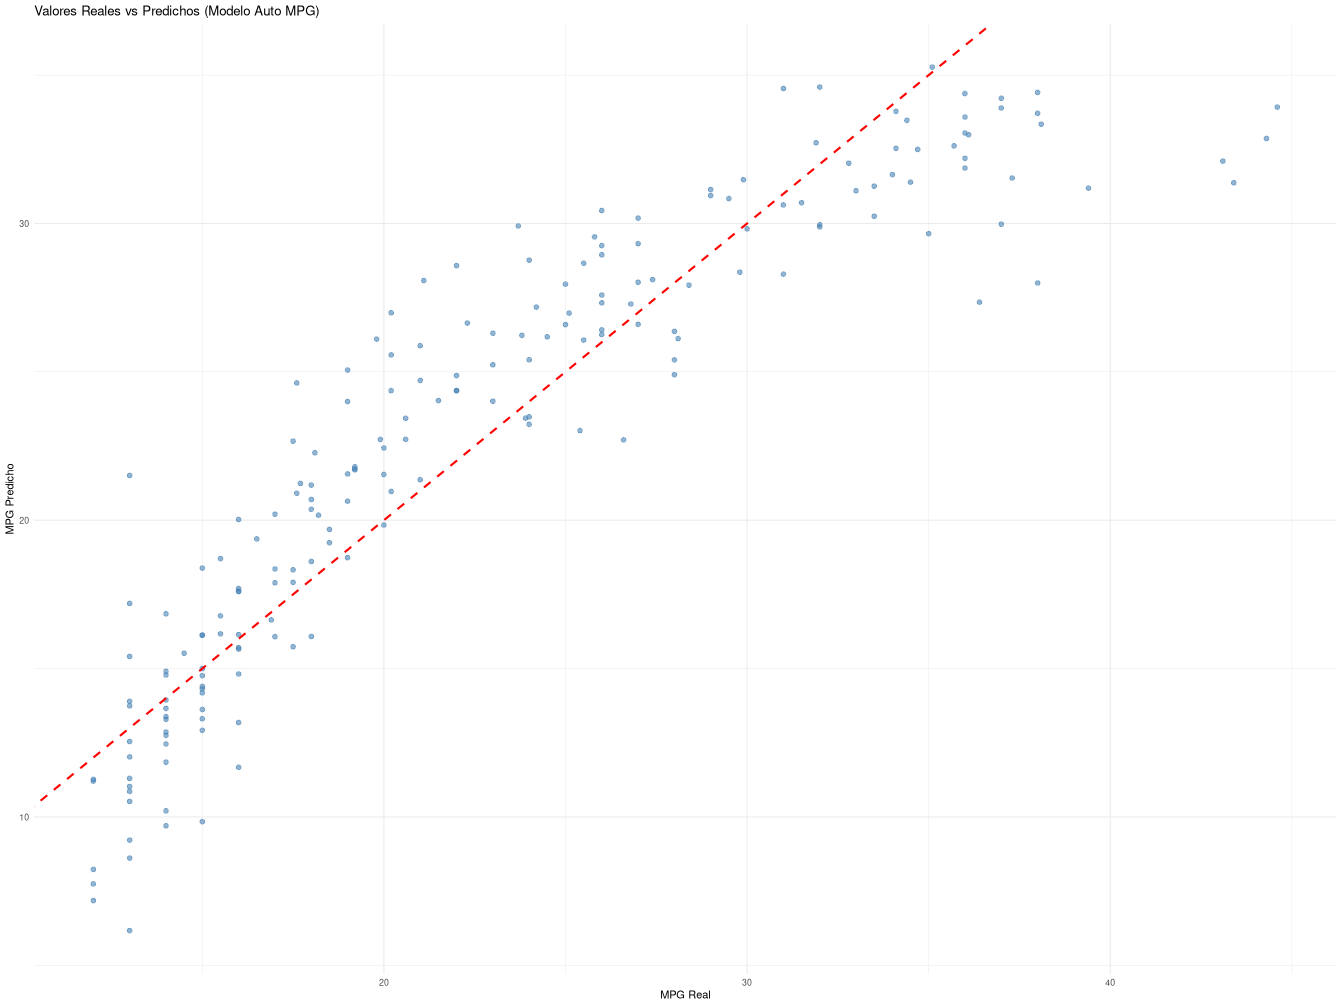


=== INTERPRETACI<U+00D3>N DEL MODELO ===
Coeficientes:
 (Intercept)       weight   horsepower         year 
-8.266159637 -0.005974675 -0.018261680  0.680814429 

R-cuadrado ajustado: 0.816791 
Error est<U+00E1>ndar residual: 3.534104 

El modelo explica aproximadamente 81.68 % de la variabilidad en MPG

=== PREDICCIONES ===
  weight horsepower year      fit      lwr      upr
1   3000        100   75 23.04473 22.47479 23.61466
2   3500        150   80 22.54838 21.36487 23.73189
3   4000        200   85 22.05203 19.58425 24.51981


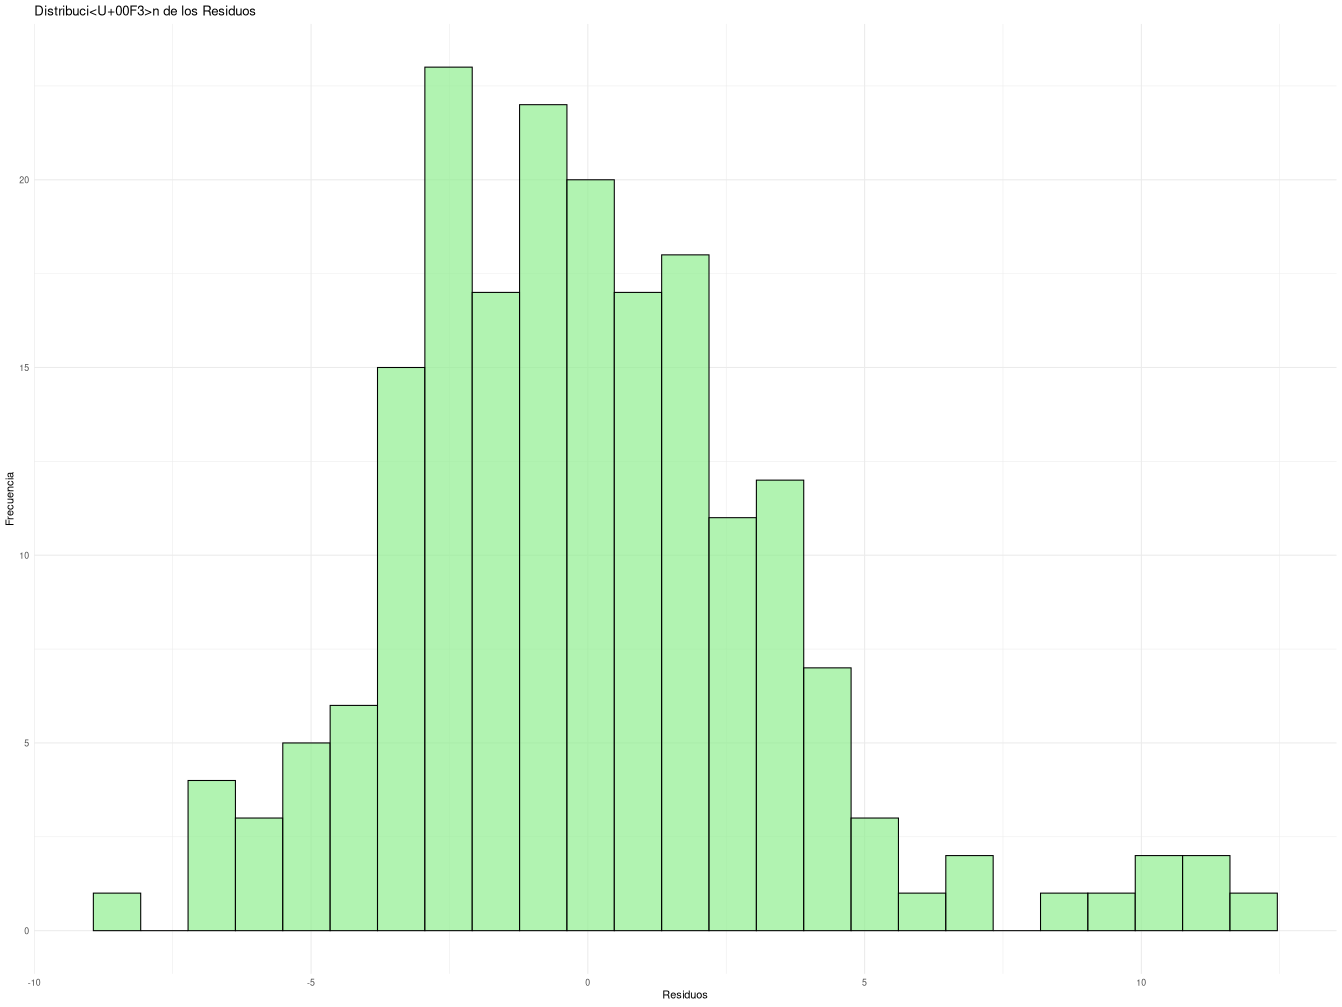

In [8]:
# ============================================
# EJEMPLO 3: Auto MPG - Dataset de UCI Repository
# ============================================

# Cargar librerías
library(ggplot2)
library(dplyr)
library(readr)

# 1. Descargar y cargar los datos desde UCI Repository
url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

# Leer los datos (separados por espacios, sin encabezado)
auto_mpg <- read_table(url, col_names = FALSE)

# Asignar nombres a las columnas
colnames(auto_mpg) <- c("mpg", "cylinders", "displacement", "horsepower", 
                        "weight", "acceleration", "year", "origin", "name")

# Ver estructura
str(auto_mpg)
head(auto_mpg)

# ============================================
# LIMPIEZA DE DATOS
# ============================================

# Convertir horsepower a numérico (algunos valores tienen "?")
auto_mpg$horsepower <- as.numeric(auto_mpg$horsepower)

# Eliminar filas con valores NA
auto_mpg_clean <- auto_mpg %>% na.omit()

cat("Filas originales:", nrow(auto_mpg), "\n")
cat("Filas después de limpieza:", nrow(auto_mpg_clean), "\n")

# Convertir variables categóricas
auto_mpg_clean$cylinders <- as.factor(auto_mpg_clean$cylinders)
auto_mpg_clean$origin <- as.factor(auto_mpg_clean$origin)

# ============================================
# ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ============================================

# Resumen estadístico
summary(auto_mpg_clean)

# Histograma de MPG
ggplot(auto_mpg_clean, aes(x = mpg)) +
  geom_histogram(bins = 20, fill = "coral", color = "black", alpha = 0.7) +
  labs(title = "Distribución del Consumo de Combustible (Auto MPG)",
       x = "Millas por Galón (MPG)",
       y = "Frecuencia") +
  theme_minimal()

# Scatter plots de MPG vs variables predictoras
ggplot(auto_mpg_clean, aes(x = weight, y = mpg)) +
  geom_point(size = 2, color = "steelblue", alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE, color = "red", size = 1) +
  labs(title = "MPG vs Peso del Automóvil",
       x = "Peso (lbs)",
       y = "MPG") +
  theme_minimal()

ggplot(auto_mpg_clean, aes(x = horsepower, y = mpg)) +
  geom_point(size = 2, color = "darkgreen", alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE, color = "red", size = 1) +
  labs(title = "MPG vs Caballos de Fuerza",
       x = "Caballos de Fuerza",
       y = "MPG") +
  theme_minimal()

ggplot(auto_mpg_clean, aes(x = displacement, y = mpg)) +
  geom_point(size = 2, color = "purple", alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE, color = "red", size = 1) +
  labs(title = "MPG vs Cilindrada",
       x = "Cilindrada (pulgadas cúbicas)",
       y = "MPG") +
  theme_minimal()

# Boxplot de MPG por número de cilindros
ggplot(auto_mpg_clean, aes(x = cylinders, y = mpg, fill = cylinders)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Distribución de MPG por Número de Cilindros",
       x = "Número de Cilindros",
       y = "Millas por Galón (MPG)") +
  theme_minimal() +
  theme(legend.position = "none")

# Boxplot de MPG por origen
ggplot(auto_mpg_clean, aes(x = origin, y = mpg, fill = origin)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Distribución de MPG por Origen del Automóvil",
       x = "Origen (1=USA, 2=Europa, 3=Japón)",
       y = "Millas por Galón (MPG)") +
  theme_minimal() +
  theme(legend.position = "none")

# ============================================
# MODELO DE REGRESIÓN LINEAL
# ============================================

# Modelo múltiple: predecir MPG usando peso, caballos de fuerza y año
modelo_auto <- lm(mpg ~ weight + horsepower + year, data = auto_mpg_clean)
summary(modelo_auto)

# Modelo más completo
modelo_auto_completo <- lm(mpg ~ weight + horsepower + displacement + 
                           acceleration + year + cylinders + origin, 
                           data = auto_mpg_clean)
summary(modelo_auto_completo)

# ============================================
# DIAGNÓSTICO DEL MODELO
# ============================================

# Gráficos de diagnóstico
par(mfrow = c(2, 2))
plot(modelo_auto)
par(mfrow = c(1, 1))

# Gráfico de valores reales vs predichos
df_pred <- data.frame(
  Real = auto_mpg_clean$mpg,
  Predicho = fitted(modelo_auto)
)

ggplot(df_pred, aes(x = Real, y = Predicho)) +
  geom_point(size = 2, color = "steelblue", alpha = 0.6) +
  geom_abline(intercept = 0, slope = 1, color = "red", 
              linetype = "dashed", size = 1) +
  labs(title = "Valores Reales vs Predichos (Modelo Auto MPG)",
       x = "MPG Real",
       y = "MPG Predicho") +
  theme_minimal()

# Histograma de residuos
ggplot(data.frame(Residuos = resid(modelo_auto)), aes(x = Residuos)) +
  geom_histogram(bins = 25, fill = "lightgreen", color = "black", alpha = 0.7) +
  labs(title = "Distribución de los Residuos",
       x = "Residuos",
       y = "Frecuencia") +
  theme_minimal()

# Interpretación
cat("\n=== INTERPRETACIÓN DEL MODELO ===\n")
cat("Coeficientes:\n")
print(coef(modelo_auto))
cat("\nR-cuadrado ajustado:", summary(modelo_auto)$adj.r.squared, "\n")
cat("Error estándar residual:", summary(modelo_auto)$sigma, "\n")
cat("\nEl modelo explica aproximadamente", 
    round(summary(modelo_auto)$adj.r.squared * 100, 2), 
    "% de la variabilidad en MPG\n")

# Predicción para nuevos datos
nuevos_datos <- data.frame(
  weight = c(3000, 3500, 4000),
  horsepower = c(100, 150, 200),
  year = c(75, 80, 85)
)

predicciones <- predict(modelo_auto, newdata = nuevos_datos, interval = "confidence")
cat("\n=== PREDICCIONES ===\n")
print(data.frame(nuevos_datos, predicciones))